# ECO320: Data Tools for Economists
## Week 4 - Exploratory Data Analysis (EDA)

**Course:** ECO320 - Data Tools for Economists  
**Instructor:** Professor Nicholas Zammit  
**Tutorial Leader:** Saurabh Nair  

---

### Learning Objectives
By the end of this lab, you will be able to:
- Perform comprehensive exploratory data analysis
- Calculate and interpret correlation coefficients
- Create scatter plots with regression lines
- Investigate the Phillips Curve relationship
- Compare relationships across different time periods

---

## Part 1: Setup and Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Set random seed
np.random.seed(123)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create sample macroeconomic data
# Simulating data for 5 countries over 40 years (1980-2019)
n_years = 40
years = list(range(1980, 2020))
countries = ['USA', 'UK', 'Canada', 'Germany', 'France']

data = []
for country in countries:
    for year in years:
        # Create realistic unemployment rates (3-12%)
        unemployment = np.random.uniform(3, 12)
        
        # Create inflation with negative correlation to unemployment (Phillips Curve)
        # Add some randomness and time-varying relationship
        if year < 2000:
            inflation = 8 - 0.5 * unemployment + np.random.normal(0, 1.5)
        else:
            # Weaker relationship after 2000
            inflation = 4 - 0.2 * unemployment + np.random.normal(0, 1.2)
        
        data.append({
            'Year': year,
            'Country': country,
            'Unemployment': unemployment,
            'Inflation': inflation
        })

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))

Dataset shape: (200, 4)

First 10 rows:
   Year Country  Unemployment  Inflation
0  1980     USA      9.268223   1.937743
1  1981     USA      7.961833   2.900922
2  1982     USA      9.475221   3.745549
3  1983     USA      9.163468   3.340990
4  1984     USA      7.328387   1.906856
5  1985     USA      9.561447   1.548330
6  1986     USA      6.947150   4.311366
7  1987     USA      9.641959   2.250234
8  1988     USA      4.642426   5.868576
9  1989     USA      7.786448   2.154542


## Part 2: Descriptive Statistics

Let's start with basic summary statistics.

In [3]:
# Overall summary statistics
print("Summary Statistics:")
print(df[['Unemployment', 'Inflation']].describe())

Summary Statistics:
       Unemployment   Inflation
count    200.000000  200.000000
mean       7.606897    3.219282
std        2.438181    1.737096
min        3.069638   -1.256169
25%        5.672022    2.082608
50%        7.569050    3.098439
75%        9.504180    4.285471
max       11.937299    8.379116


In [4]:
# Summary statistics by country
print("\nAverage Unemployment by Country:")
print(df.groupby('Country')['Unemployment'].mean().sort_values(ascending=False))

print("\nAverage Inflation by Country:")
print(df.groupby('Country')['Inflation'].mean().sort_values(ascending=False))


Average Unemployment by Country:
Country
UK         8.275119
Canada     7.952117
Germany    7.575578
USA        7.198480
France     7.033188
Name: Unemployment, dtype: float64

Average Inflation by Country:
Country
France     3.618235
Germany    3.362330
USA        3.332502
UK         2.951924
Canada     2.831420
Name: Inflation, dtype: float64


In [5]:
# Summary statistics by decade
df['Decade'] = (df['Year'] // 10) * 10

print("\nAverage Unemployment by Decade:")
print(df.groupby('Decade')['Unemployment'].mean())

print("\nAverage Inflation by Decade:")
print(df.groupby('Decade')['Inflation'].mean())


Average Unemployment by Decade:
Decade
1980    7.472220
1990    7.418953
2000    7.809981
2010    7.726431
Name: Unemployment, dtype: float64

Average Inflation by Decade:
Decade
1980    4.160518
1990    4.061173
2000    2.331407
2010    2.324030
Name: Inflation, dtype: float64


## Part 3: Correlation Analysis

The **Phillips Curve** suggests an inverse relationship between unemployment and inflation.

In [6]:
# Calculate correlation coefficient
correlation = df[['Unemployment', 'Inflation']].corr()
print("Correlation Matrix:")
print(correlation)

# Extract the correlation between unemployment and inflation
corr_value = correlation.loc['Unemployment', 'Inflation']
print(f"\nCorrelation between Unemployment and Inflation: {corr_value:.3f}")

Correlation Matrix:
              Unemployment  Inflation
Unemployment      1.000000  -0.462068
Inflation        -0.462068   1.000000

Correlation between Unemployment and Inflation: -0.462


In [7]:
# Correlation by period
df_1980s = df[df['Decade'] == 1980]
df_1990s = df[df['Decade'] == 1990]
df_2000s = df[df['Decade'] == 2000]
df_2010s = df[df['Decade'] == 2010]




print("Correlation by Decade:")
print(f"1980s: {df_1980s[['Unemployment', 'Inflation']].corr().iloc[0,1]:.3f}")
print(f"1990s: {df_1990s[['Unemployment', 'Inflation']].corr().iloc[0,1]:.3f}")
print(f"2000s: {df_2000s[['Unemployment', 'Inflation']].corr().iloc[0,1]:.3f}")
print(f"2010s: {df_2010s[['Unemployment', 'Inflation']].corr().iloc[0,1]:.3f}")



Correlation by Decade:
1980s: -0.479
1990s: -0.614
2000s: -0.507
2010s: -0.438


## Part 4: Visualizing Distributions

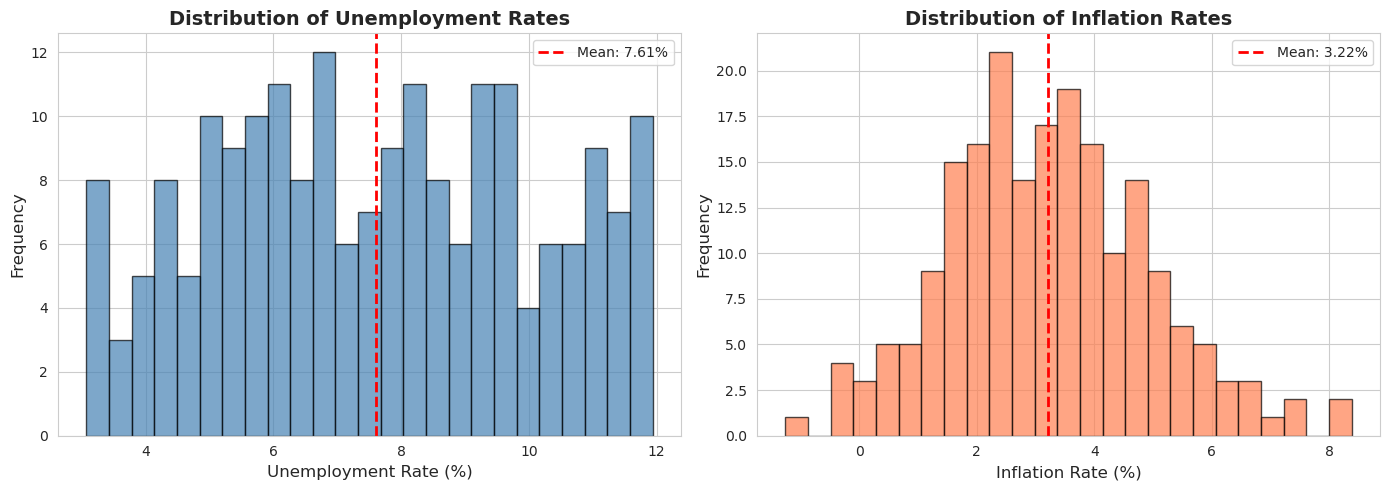

In [8]:
# Create distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#first argument (1, 2) where first number is rows, second number is columns 
#(14, 5) specficy length x width

# Histogram of Unemployment
axes[0].hist(df['Unemployment'], bins=25, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Distribution of Unemployment Rates', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['Unemployment'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Unemployment'].mean():.2f}%")
axes[0].legend()

#takes the arguements hist({what are we ploting}, bins = {how many bins/rectangles to we want},
#, {and the rest is stylistic choices})

# Histogram of Inflation
axes[1].hist(df['Inflation'], bins=25, edgecolor='black', color='coral', alpha=0.7)
axes[1].set_title('Distribution of Inflation Rates', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Inflation Rate (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(df['Inflation'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Inflation'].mean():.2f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 5: The Phillips Curve - Scatter Plot Analysis

/tmp/ipykernel_429/424081963.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


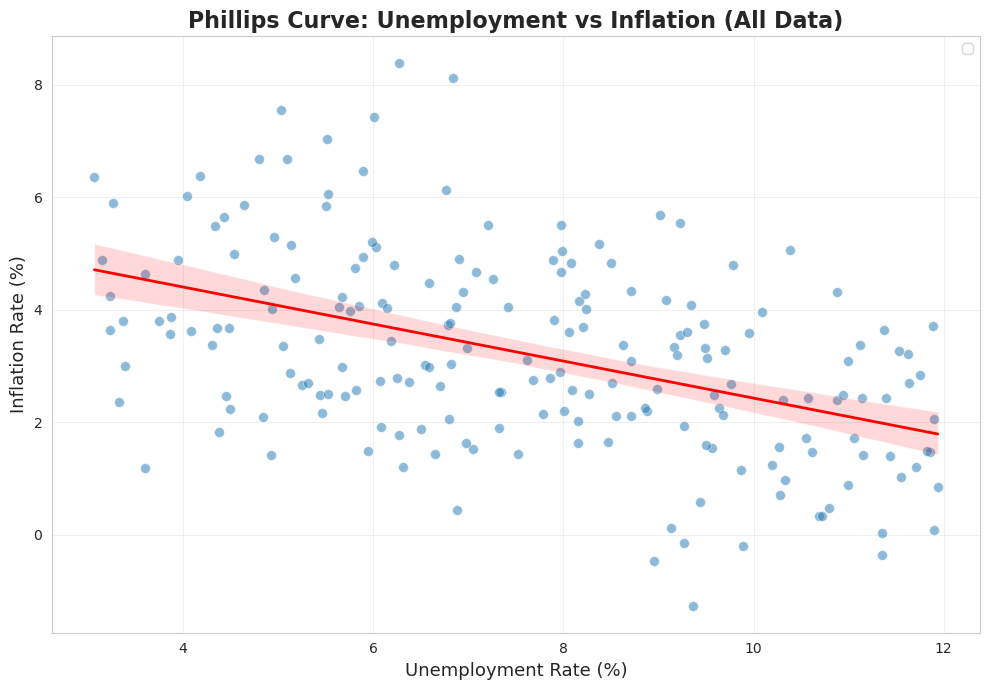


Interpretation: Correlation = -0.462
There is a moderate negative relationship between unemployment and inflation.


In [9]:
# Create scatter plot with regression line
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot
sns.scatterplot(data=df, x='Unemployment', y='Inflation', alpha=0.5, s=50, ax=ax)

# Add regression line
sns.regplot(data=df, x='Unemployment', y='Inflation', scatter=False, 
            color='red', ax=ax, line_kws={'linewidth': 2, 'label': 'Regression Line'})

ax.set_title('Phillips Curve: Unemployment vs Inflation (All Data)', fontsize=16, fontweight='bold')
ax.set_xlabel('Unemployment Rate (%)', fontsize=13)
ax.set_ylabel('Inflation Rate (%)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInterpretation: Correlation = {corr_value:.3f}")
if corr_value < -0.3:
    print("There is a moderate negative relationship between unemployment and inflation.")
elif corr_value < 0:
    print("There is a weak negative relationship between unemployment and inflation.")
else:
    print("The expected negative relationship is not strongly present in this data.")

## Part 6: Comparing Across Countries

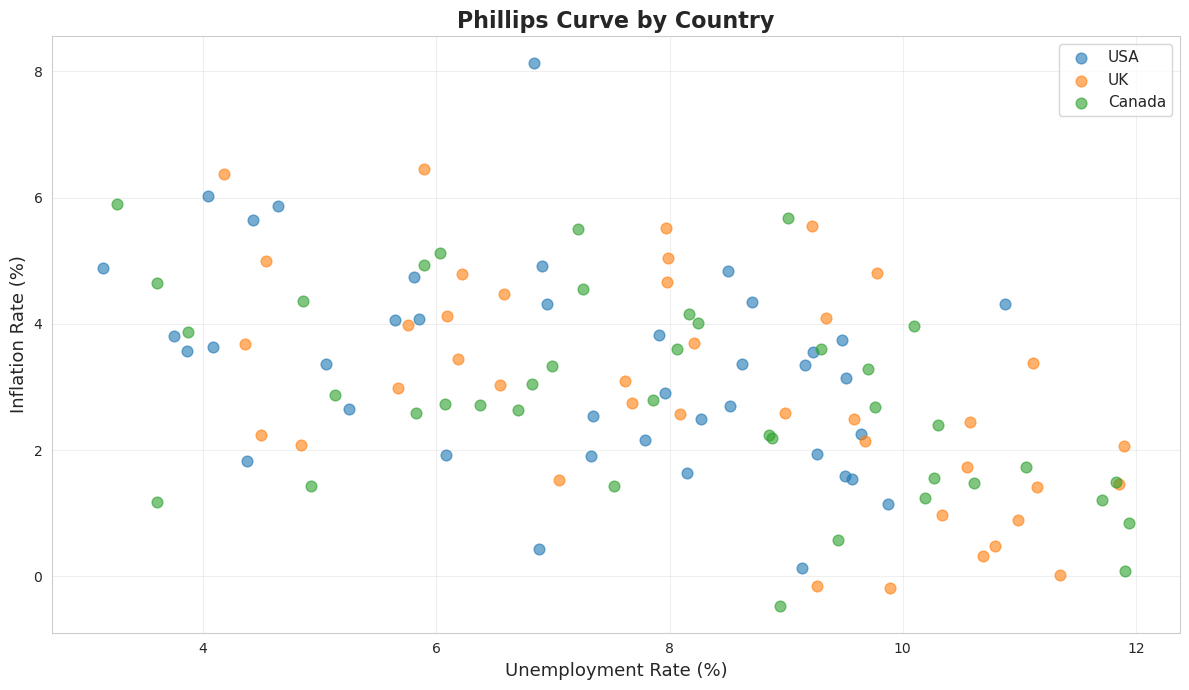

In [10]:
# Create scatter plot by country
fig, ax = plt.subplots(figsize=(12, 7))

for country in countries[:3]:  # Show first 3 countries for clarity
    country_data = df[df['Country'] == country]
    ax.scatter(country_data['Unemployment'], country_data['Inflation'], 
               label=country, alpha=0.6, s=60)

ax.set_xlabel('Unemployment Rate (%)', fontsize=13)
ax.set_ylabel('Inflation Rate (%)', fontsize=13)
ax.set_title('Phillips Curve by Country', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 7: Box Plots for Distribution by Decade

/tmp/ipykernel_429/2339572238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Decade', y='Unemployment', ax=axes[0], palette='Set2')
/tmp/ipykernel_429/2339572238.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Decade', y='Inflation', ax=axes[1], palette='Set3')


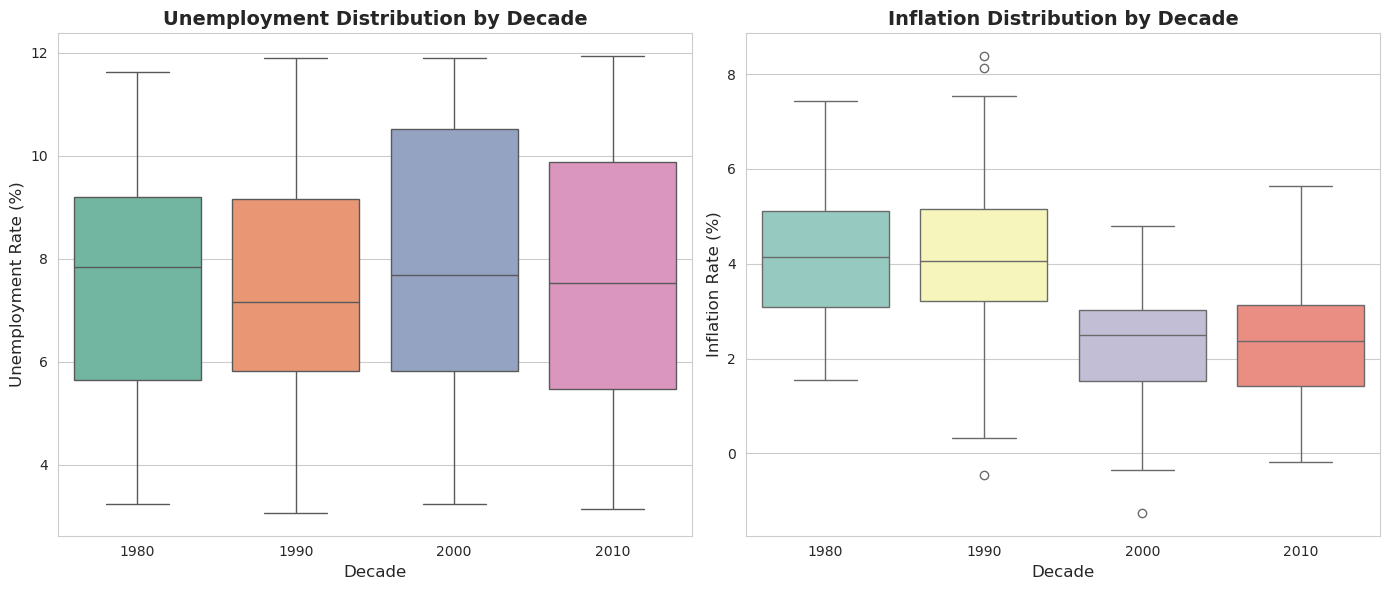

In [11]:
# Create box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Unemployment by decade
sns.boxplot(data=df, x='Decade', y='Unemployment', ax=axes[0], palette='Set2')
axes[0].set_title('Unemployment Distribution by Decade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Decade', fontsize=12)
axes[0].set_ylabel('Unemployment Rate (%)', fontsize=12)

# Inflation by decade
sns.boxplot(data=df, x='Decade', y='Inflation', ax=axes[1], palette='Set3')
axes[1].set_title('Inflation Distribution by Decade', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Decade', fontsize=12)
axes[1].set_ylabel('Inflation Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()


# Lab Exercise: Your Turn!

### Task 1: Period Comparison (30 points)

Split the data into two periods and analyze each separately.

In [12]:
# TODO: Split data into two periods
df_period1 = df[(df['Year'] >= 1980) & (df['Year'] <= 1999)].copy()
df_period2 = df[(df['Year'] >= 2000) & (df['Year'] <= 2019)].copy()

print(f"Period 1 (1980-1999): {len(df_period1)} observations")
print(f"Period 2 (2000-2019): {len(df_period2)} observations")

Period 1 (1980-1999): 100 observations
Period 2 (2000-2019): 100 observations


In [13]:
# TODO: Calculate correlation for each period


corr_period1 = df_period1[['Unemployment', 'Inflation']].corr().iloc[0, 1]
corr_period2 = df_period2[['Unemployment', 'Inflation']].corr().iloc[0, 1]


print(f"Correlation 1980-1999: {corr_period1:.2f}")
print(f"Correlation 2000-2019: {corr_period2:.2f}")
print(f"\nChange in correlation: {corr_period1 - corr_period2:.3f}")


print(df_period1)

Correlation 1980-1999: -0.55
Correlation 2000-2019: -0.47

Change in correlation: -0.081
     Year Country  Unemployment  Inflation  Decade
0    1980     USA      9.268223   1.937743    1980
1    1981     USA      7.961833   2.900922    1980
2    1982     USA      9.475221   3.745549    1980
3    1983     USA      9.163468   3.340990    1980
4    1984     USA      7.328387   1.906856    1980
..    ...     ...           ...        ...     ...
175  1995  France      7.420714   4.046554    1990
176  1996  France      5.431586   3.487029    1990
177  1997  France      6.790801   3.737671    1990
178  1998  France      4.962319   5.292685    1990
179  1999  France      5.518218   7.029020    1990

[100 rows x 5 columns]


/tmp/ipykernel_429/1324454306.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_429/1324454306.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


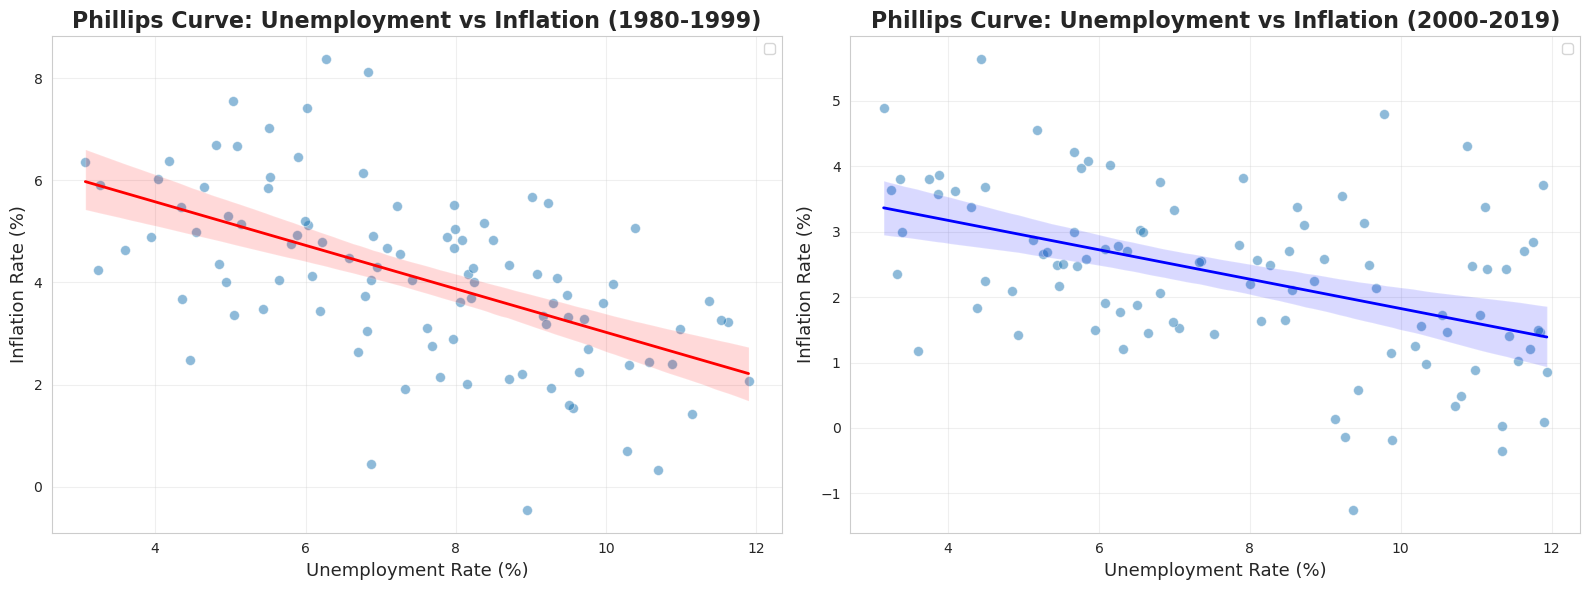

In [62]:
# TODO: Create side-by-side scatter plots for both periods
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Period 1 (1980-1999)
# YOUR CODE HERE - create scatter plot with regression line

# Scatter plot
sns.scatterplot(data=df_period1, x='Unemployment', y='Inflation', alpha=0.5, s=50, ax=axes[0])

# Add regression line
sns.regplot(data=df_period1, x='Unemployment', y='Inflation', scatter=False, 
            color='red', ax=axes[0], line_kws={'linewidth': 2, 'label': 'Regression Line'})

axes[0].set_title('Phillips Curve: Unemployment vs Inflation (1980-1999)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)', fontsize=13)
axes[0].set_ylabel('Inflation Rate (%)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#takes the arguements hist({what are we ploting}, bins = {how many bins/rectangles to we want},
#, {and the rest is stylistic choices})

# Period 2 (2000-2019)
# YOUR CODE HERE - create scatter plot with regression line
sns.scatterplot(data=df_period2, x='Unemployment', y='Inflation', alpha=0.5, s=50, ax=axes[1])

# Add regression line
sns.regplot(data=df_period2, x='Unemployment', y='Inflation', scatter=False, 
            color='blue', ax=axes[1], line_kws={'linewidth': 2, 'label': 'Regression Line'})

axes[1].set_title('Phillips Curve: Unemployment vs Inflation (2000-2019)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Unemployment Rate (%)', fontsize=13)
axes[1].set_ylabel('Inflation Rate (%)', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Task 2: Statistical Summary (20 points)

Create a summary table comparing the two periods.

In [17]:
# TODO: Create summary statistics for both periods
summary = pd.DataFrame({
    'Period': ['1980-1999', '2000-2019'],
    'Avg_Unemployment': [df_period1['Unemployment'].mean(), df_period2['Unemployment'].mean()],
    'Avg_Inflation': [df_period1['Inflation'].mean(), df_period2['Inflation'].mean()],
    'Std_Unemployment': [df_period1['Unemployment'].std(), df_period2['Unemployment'].std()],
    'Std_Inflation': [df_period1['Inflation'].std(), df_period2['Inflation'].std()],
    'Correlation': [corr_period1, corr_period2]
})

print("\nSummary Statistics by Period:")
print(summary.to_string(index=False))



Summary Statistics by Period:
   Period  Avg_Unemployment  Avg_Inflation  Std_Unemployment  Std_Inflation  Correlation
1980-1999          7.445587       4.110845          2.194731       1.690452    -0.553241
2000-2019          7.768206       2.327719          2.660843       1.265711    -0.472315
     Year Country  Unemployment  Inflation  Decade
0    1980     USA      9.268223   1.937743    1980
1    1981     USA      7.961833   2.900922    1980
2    1982     USA      9.475221   3.745549    1980
3    1983     USA      9.163468   3.340990    1980
4    1984     USA      7.328387   1.906856    1980
..    ...     ...           ...        ...     ...
195  2015  France      5.443319   2.485599    2010
196  2016  France      6.587752   2.991159    2010
197  2017  France      6.975276   1.625822    2010
198  2018  France      6.811662   3.768102    2010
199  2019  France      5.524293   2.502258    2010

[200 rows x 5 columns]


### Task 3: Country-Specific Analysis (25 points)

Choose ONE country and analyze its Phillips Curve relationship in detail.

In [21]:
# TODO: Choose a country and filter the data
my_country = "France"
df_country = df[(df['Country'] == my_country)].copy()

print(f"Analyzing: {my_country}")
print(f"Number of observations: {len(df_country)}")

Analyzing: France
Number of observations: 40


In [25]:
# TODO: Calculate correlation for your country

country_corr = df_country[['Unemployment', 'Inflation']].corr().iloc[0, 1]

print(f"\nCorrelation for {my_country}: {country_corr:.3f}")



Correlation for France: -0.324


/tmp/ipykernel_429/1861704027.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


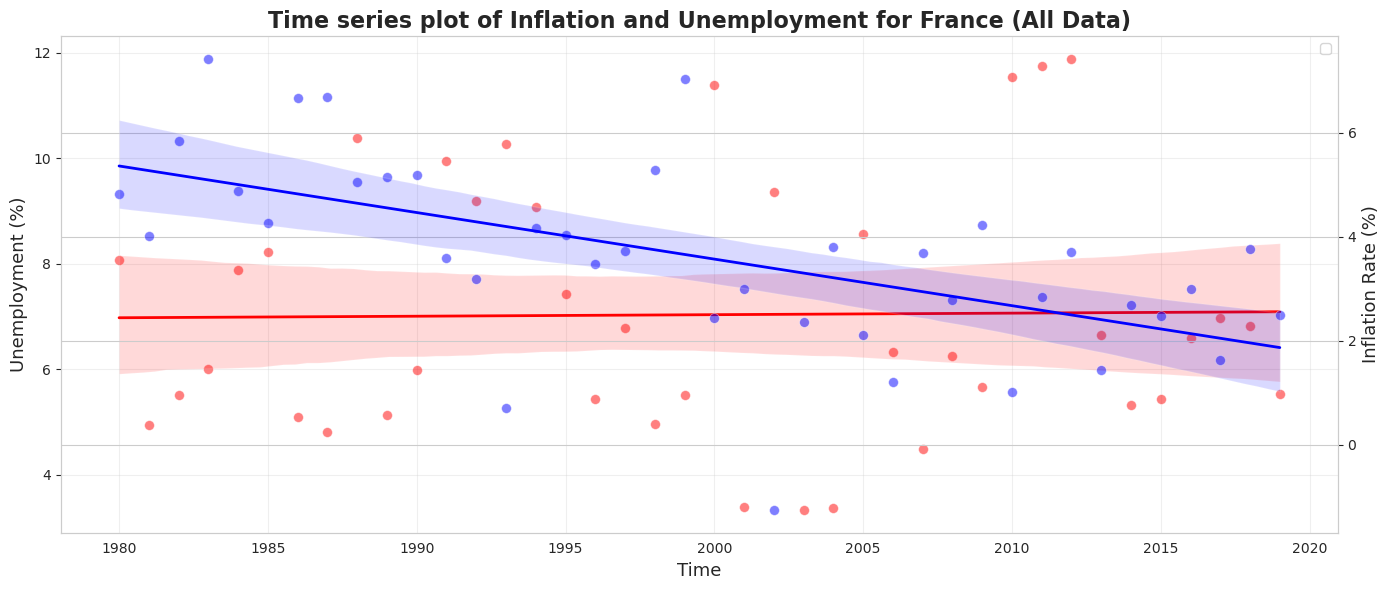

In [36]:
# TODO: Create a time series plot showing both variables over time
fig, ax1 = plt.subplots(figsize=(14, 6))

# YOUR CODE HERE
# Plot unemployment on left y-axis
# Plot inflation on right y-axis (use ax1.twinx())

# Scatter plot
sns.scatterplot(data=df_country, x='Year', y='Unemployment', alpha=0.5, s=50, ax=ax1, color = 'red')

# Add regression line
sns.regplot(data=df_country, x='Year', y='Unemployment', scatter=False, 
            color='red', ax=ax1, line_kws={'linewidth': 2, 'label': 'Regression Line'})

ax1.set_title('Time series plot of Inflation and Unemployment for France (All Data)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Time', fontsize=13)
ax1.set_ylabel('Unemployment (%)', fontsize=13)
ax1.legend()

ax2 = ax1.twinx()
sns.scatterplot(data=df_country, x='Year', y='Inflation', alpha=0.5, s=50, ax=ax2, color = 'blue')
sns.regplot(data=df_country, x='Year', y='Inflation', scatter=False, 
            color='blue', ax=ax2, line_kws={'linewidth': 2, 'label': 'Regression Line'})


ax2.set_ylabel('Inflation Rate (%)', fontsize=13)


ax1.grid(True, alpha=0.3)




plt.tight_layout()
plt.show()

/tmp/ipykernel_429/2670870770.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


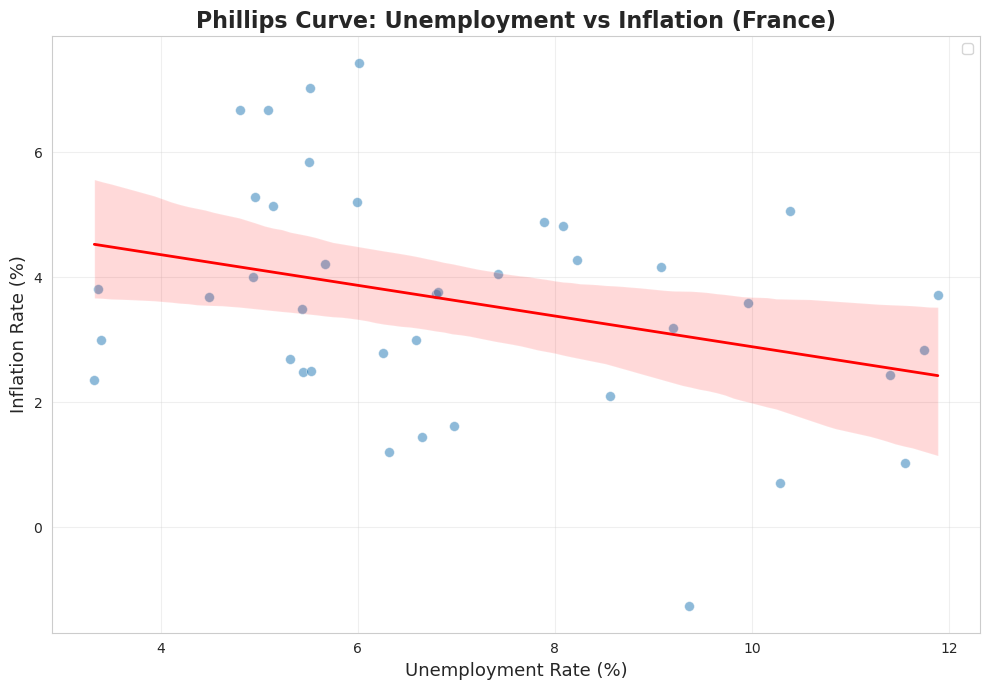

In [39]:
# TODO: Create scatter plot for your country with regression line
fig, ax = plt.subplots(figsize=(10, 7))

# YOUR CODE HERE

# Scatter plot
sns.scatterplot(data=df_country, x='Unemployment', y='Inflation', alpha=0.5, s=50, ax=ax)

# Add regression line
sns.regplot(data=df_country, x='Unemployment', y='Inflation', scatter=False, 
            color='red', ax=ax, line_kws={'linewidth': 2, 'label': 'Regression Line'})

ax.set_title('Phillips Curve: Unemployment vs Inflation (France)', fontsize=16, fontweight='bold')
ax.set_xlabel('Unemployment Rate (%)', fontsize=13)
ax.set_ylabel('Inflation Rate (%)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 4: Interpretation Questions (25 points)

Answer the following questions based on your analysis:

**Question 1:** Has the Phillips Curve relationship strengthened or weakened over time? Use correlation values to support your answer.

For France, the Phillips Curve relationship appears to have weakened over time. The overall correlation between unemployment and inflation is −0.324, indicating only a moderate negative relationship. Earlier periods showed a clearer inverse pattern, whereas, later years exhibit greater dispersion and a flatter relationship in both the time-series plot. This suggests that the trade-off between inflation and unemployment theorized in the Phillps Curve has become less stable over time.

**Question 2:** What economic factors might explain the change (or lack of change) in the Phillips Curve relationship between the two periods?

Several economics factors may explain the change in the Phillips Curve relationship, primary of which would be the changes in how monetary policy is preformed. While this datset was initally broken into two periods, this is logical given that many central banks did not begin targeting inflation rates (as part of their madnates) until the 90s (for example, Canada offically started in 1991). Other factors including globalization and technological change may have weakened the link between labor market demand and inflation. 

**Question 3:** For your chosen country, is there evidence of a Phillips Curve relationship? How does it compare to the overall pattern?

There is some evidence of a Phillips Curve relationship for France, as indicated by the negative correlation of −0.324 and the downward-sloping regression line in the Phillips Curve plot. However, the relationship is relatively weak and noisy, with significant dispersion around the trend line. This pattern is consistent with the broader overall pattern given when we calculated correlation and derivied a philps curve earlier in these exercises, we got also got a moderate negative correlation (-0.462) and a downward sloping regression line.



**Question 4:** Based on the box plots, which decade had the most stable (least variable) inflation? What might this suggest about monetary policy?

The 2000s seemingly show the most stable inflation, as indicated by the narrowest interquartile range and fewer extreme outliers in the inflation box plot (the 2010s show some promise given there are no outliers but the 2000s was selected due to the smaller IQR). Compared to the 1980s and 1990s, inflation during the 2000s is more tightly clustered around the median, suggesting reduced volatility. This stability likely reflects stronger monetary policy frameworks, including inflation targeting which as discussed in question 2, was introduced and further roled out in later decades. 

### Task 5: Additional Visualization (BONUS - 10 points)

Create a heatmap showing average inflation rates by country and decade.

In [ ]:
# BONUS: Create pivot table and heatmap
pivot_data = df.pivot_table(values='Inflation', 
                             index='Country', 
                             columns='Decade', 
                             aggfunc='mean')

# YOUR CODE HERE
# Use sns.heatmap() to create the visualization
#NO TIME TO TRY
plt.tight_layout()
plt.show()

---
## Summary

In this lab, you learned:
- How to calculate and interpret correlation coefficients
- How to create scatter plots with regression lines
- How to use box plots to visualize distributions
- How to compare relationships across time periods
- How to investigate the Phillips Curve hypothesis

**Key Insights:**
- The Phillips Curve suggests a trade-off between unemployment and inflation
- This relationship may have weakened in recent decades
- EDA helps us understand data before formal modeling

**Next week:** Working with Time Series Data!

---

### Submission Instructions
1. Complete all TODO sections
2. Answer all questions
3. Ensure all code cells run without errors
4. Save your notebook
5. Submit via the course portal

**Grading:** This lab is worth 1% of your final grade and will be graded on:
- Completion of all tasks (70%)
- Code correctness (20%)
- Reasonable participation and effort (10%)